In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv("adult_income.csv")

# Clean up strings
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

# Encode target
df['income'] = LabelEncoder().fit_transform(df['income'])  # >50K = 1, <=50K = 0


/Users/sandilranasinghe/Work/workshops/datastorm/code/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Drop target temporarily
X = df.drop(columns=['income'])
y = df['income']

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X)

# Standardize features (important for PCA/t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print(f"Original feature count: {X_encoded.shape[1]}")


Original feature count: 105


## PCA

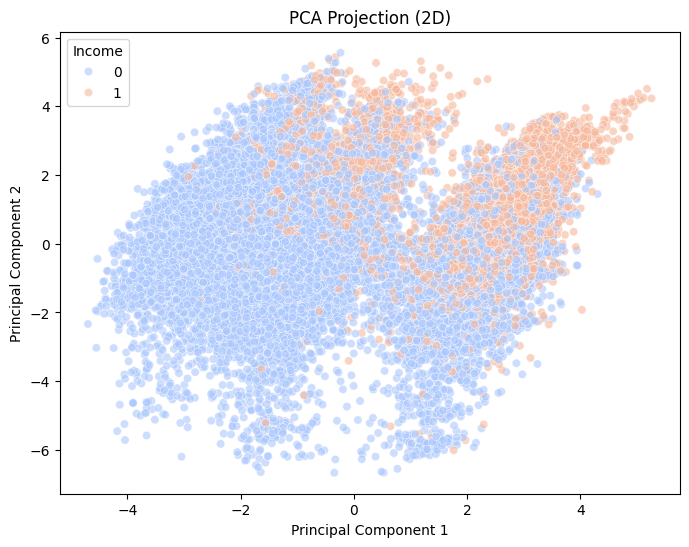

Explained variance: 0.07


In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA result
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.6)
plt.title("PCA Projection (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Income')
plt.show()

print(f"Explained variance: {pca.explained_variance_ratio_.sum():.2f}")


/var/folders/mt/hgtqnnf96rvbcm8f8hlb2m640000gn/T/ipykernel_30781/356442564.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC', y='Explained Variance', data=pca_df, palette='viridis')


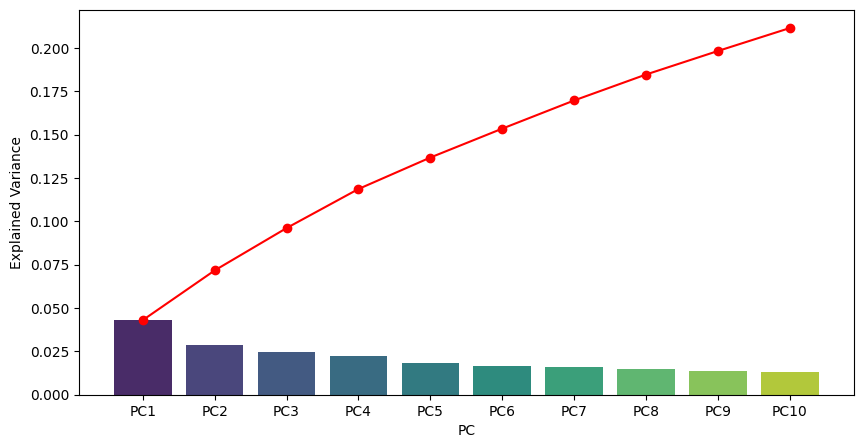

In [5]:
# Number of components to analyze
n_components = min(10, X_scaled.shape[1])  # up to 10 or fewer if fewer features

# Re-run PCA with more components for analysis
pca_full = PCA(n_components=n_components)
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Create a DataFrame for plotting
pca_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(n_components)],
    'Explained Variance': explained_variance,
    'Cumulative Variance': cumulative_variance
})

# Bar plot of explained variance
plt.figure(figsize=(10, 5))
sns.barplot(x='PC', y='Explained Variance', data=pca_df, palette='viridis')
plt.plot(pca_df['PC'], pca_df['Cumulative Variance'], marker='o', color='red', label='Cumulative')


### Other Methods

/Users/sandilranasinghe/Work/workshops/datastorm/code/venv/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


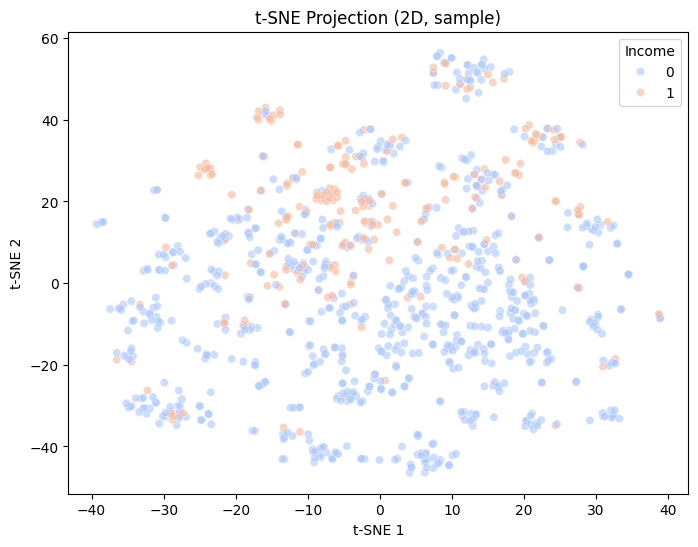

In [5]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled[:1000])  # sample to reduce computation

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y[:1000], palette='coolwarm', alpha=0.6)
plt.title("t-SNE Projection (2D, sample)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title='Income')
plt.show()


/Users/sandilranasinghe/Work/workshops/datastorm/code/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sandilranasinghe/Work/workshops/datastorm/code/venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


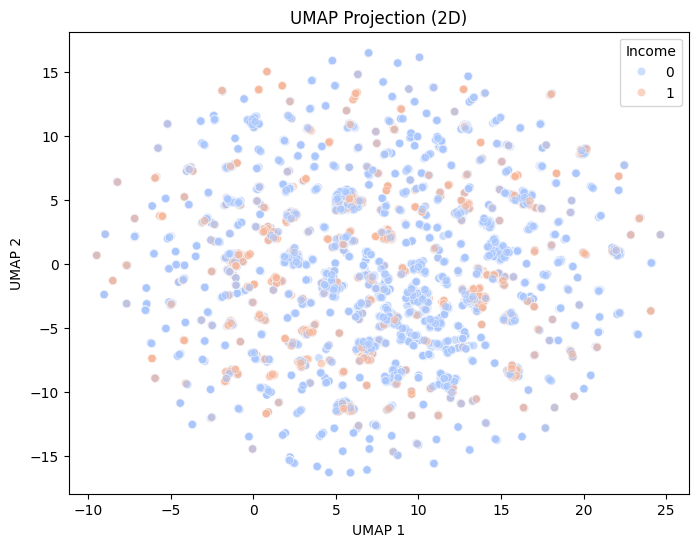

In [6]:
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y, palette='coolwarm', alpha=0.6)
plt.title("UMAP Projection (2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title='Income')
plt.show()
